In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from PIL import Image, UnidentifiedImageError
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Task 3: Load trained model

In [41]:
train_mean = 0.606
train_std = 0.1944


class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.transform = transform
        self.valid_indices = []
        for i in range(len(self.dataset)):
            path, _ = self.dataset.samples[i]
            try:
                with open(path, "rb") as f:
                    Image.open(f).verify()
                self.valid_indices.append(i)
            except (UnidentifiedImageError, OSError):
                print(f"Skipping corrupted image: {path}")

        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.targets = [self.dataset.targets[i] for i in self.valid_indices]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        return self.dataset[self.valid_indices[idx]]


val_test_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[train_mean, train_mean, train_mean],
            std=[train_std, train_std, train_std],
        ),
    ]
)

test_dataset = SafeImageFolder(
    root="data_project_gray/test", transform=val_test_transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [42]:
model_latent = models.resnet50()

num_features = model_latent.fc.in_features
model_latent.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_latent.load_state_dict(
    torch.load("resnet50_finetuned_best.pth", map_location=device)
)
model_latent = model_latent.to(device)

model_latent.eval()  # evaluation mode
model_latent.fc = nn.Identity()  # remove last layer

### Extract latent representations

In [44]:
# get full model
model_full = models.resnet50()
model_full.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))
model_full.load_state_dict(
    torch.load("resnet50_finetuned_best.pth", map_location=device)
)
model_full = model_full.to(device)
model_full.eval()

latent_features_list = []
true_labels_list = []
pred_labels_list = []
confidences_list = []

In [45]:
with torch.no_grad():
    for X, y in test_loader:
        X_device = X.to(device)

        # "Extract the latent feature vector from the last hidden layer"
        features = model_latent(X_device)

        # Prediction with full model
        logits = model_full(X_device)
        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).int()
        # "Store for each sample..."
        latent_features_list.append(features.cpu().numpy())
        true_labels_list.append(y.numpy())
        pred_labels_list.append(preds.cpu().numpy())
        confidences_list.append(probs.cpu().numpy())


latent_features = np.concatenate(latent_features_list, axis=0)
true_labels = np.concatenate(true_labels_list, axis=0)
pred_labels = np.concatenate(pred_labels_list, axis=0)
confidences = np.concatenate(confidences_list, axis=0)


##### Dimensionality reduction

In [46]:
# PCA
pca = PCA(n_components=2, random_state=42)
latent_pca = pca.fit_transform(latent_features)

In [47]:
#t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_features)

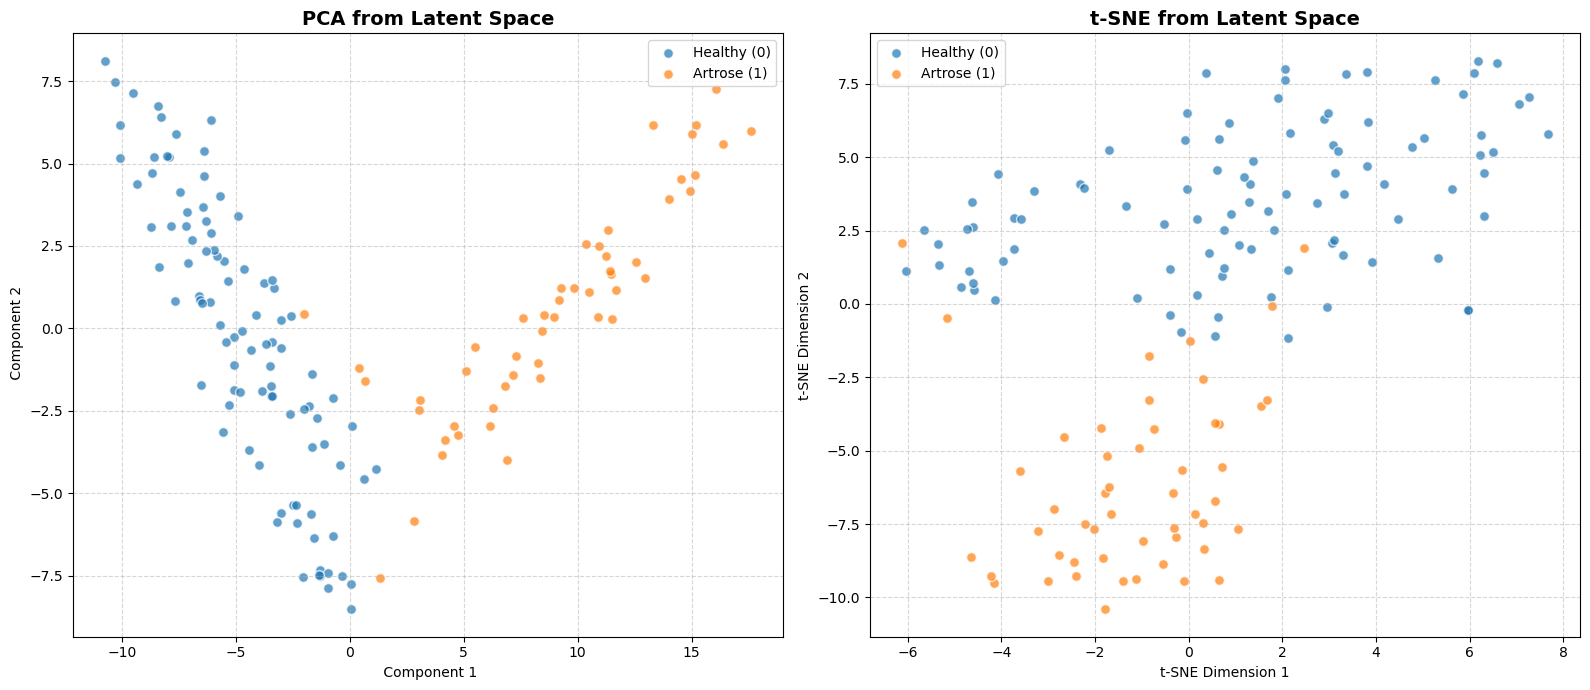

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#1f77b4', '#ff7f0e'] # Blue = healthy, orange= artrose
target_names = ['Healthy (0)', 'Artrose (1)']

#PCA
for i, color, target_name in zip([0, 1], colors, target_names):
    axes[0].scatter(latent_pca[true_labels == i, 0],
                    latent_pca[true_labels == i, 1],
                    color=color, alpha=0.7, label=target_name, edgecolors='w', s=50)
axes[0].set_title("PCA from Latent Space", fontsize=14, fontweight='bold')
axes[0].set_xlabel(" Component 1")
axes[0].set_ylabel(" Component 2")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

#t-SNE
for i, color, target_name in zip([0, 1], colors, target_names):
    axes[1].scatter(latent_tsne[true_labels == i, 0],
                    latent_tsne[true_labels == i, 1],
                    color=color, alpha=0.7, label=target_name, edgecolors='w', s=50)
axes[1].set_title("t-SNE from Latent Space", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

#### Comparison of PCA and t-SNE

PCA:
The PCA scatter plot demonstrates a very effective separation, mostly along the component 1 (horizontal) axis. Most healthy samples are located on one side of the plot, while osteoarthritis samples are primarily located on the opposite side. This indicates that a significant portion of the variance in the latent feature space is aligned with class-related differences. However, the separation is not perfect, as some overlap between classes is still visible.

Additionally, the osteoarthritis class appears more compact, whereas the healthy class is more dispersed along a linear direction. This suggests higher intra-class variability within the healthy samples. A number of misclassified or ambiguous samples are also located near the boundary between the two clusters.

t-SNE: The t-SNE scatter plot isn't devided in clear clusters like the PCA, it is more like a single cluster, where the classes are seperate on each side. Here again, some samples appear embedded in the opposite class cluster, which are ambiguous or difficult cases.

#### Inspection of misclassified samples

In [49]:
true_flat = true_labels.flatten()
pred_flat = pred_labels.flatten()
error_indices = np.where(true_flat != pred_flat)[0]
correct_indices = np.where(true_flat == pred_flat)[0]

num_to_show = min(3, len(error_indices))

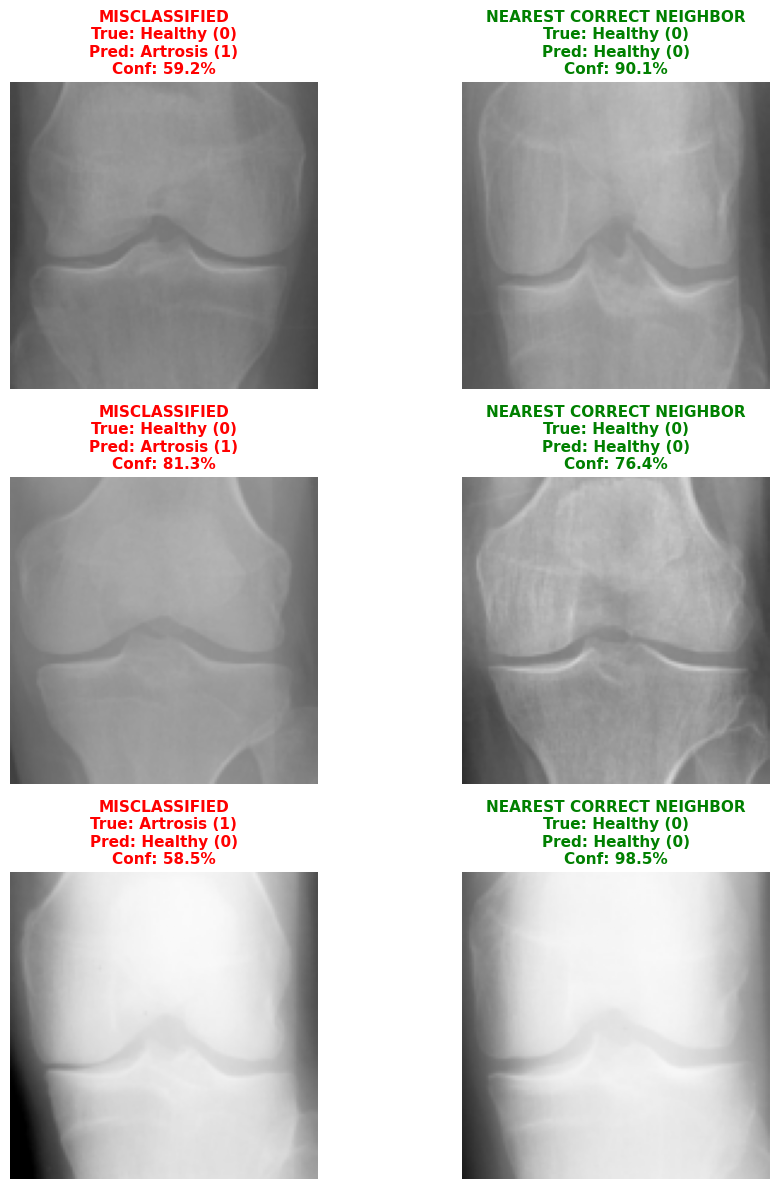

In [50]:
fig, axes = plt.subplots(num_to_show, 2, figsize=(10, 4 * num_to_show))
if num_to_show == 1:
    axes = [axes]

target_names = ['Healthy (0)', 'Artrosis (1)']

def imshow_denorm(tensor, ax, title, is_error):
    mean = torch.tensor([0.606, 0.606, 0.606]).view(3, 1, 1)
    std = torch.tensor([0.1944, 0.1944, 0.1944]).view(3, 1, 1)
    img = tensor * std + mean
    img = img.clamp(0, 1).numpy().transpose(1, 2, 0)
    ax.imshow(img)

    color = 'red' if is_error else 'green'
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.axis('off')

for i in range(num_to_show):
    err_idx = error_indices[i]
    err_true = int(true_labels[err_idx])
    err_pred = int(pred_labels[err_idx].item())
    err_conf = float(confidences[err_idx].item())
    if err_pred == 0:
        err_conf = 1.0 - err_conf

    distances = np.linalg.norm(latent_features[correct_indices] - latent_features[err_idx], axis=1)
    closest_correct_idx = correct_indices[np.argmin(distances)]

    corr_true = int(true_labels[closest_correct_idx])
    corr_pred = int(pred_labels[closest_correct_idx].item())
    corr_conf = float(confidences[closest_correct_idx].item())
    if corr_pred == 0:
        corr_conf = 1.0 - corr_conf

    img_err, _ = test_dataset[err_idx]
    title_err = f"MISCLASSIFIED\nTrue: {target_names[err_true]}\nPred: {target_names[err_pred]}\nConf: {err_conf:.1%}"
    imshow_denorm(img_err, axes[i][0], title_err, is_error=True)

    img_corr, _ = test_dataset[closest_correct_idx]
    title_corr = f"NEAREST CORRECT NEIGHBOR\nTrue: {target_names[corr_true]}\nPred: {target_names[corr_pred]}\nConf: {corr_conf:.1%}"
    imshow_denorm(img_corr, axes[i][1], title_corr, is_error=False)


plt.tight_layout()
plt.show()

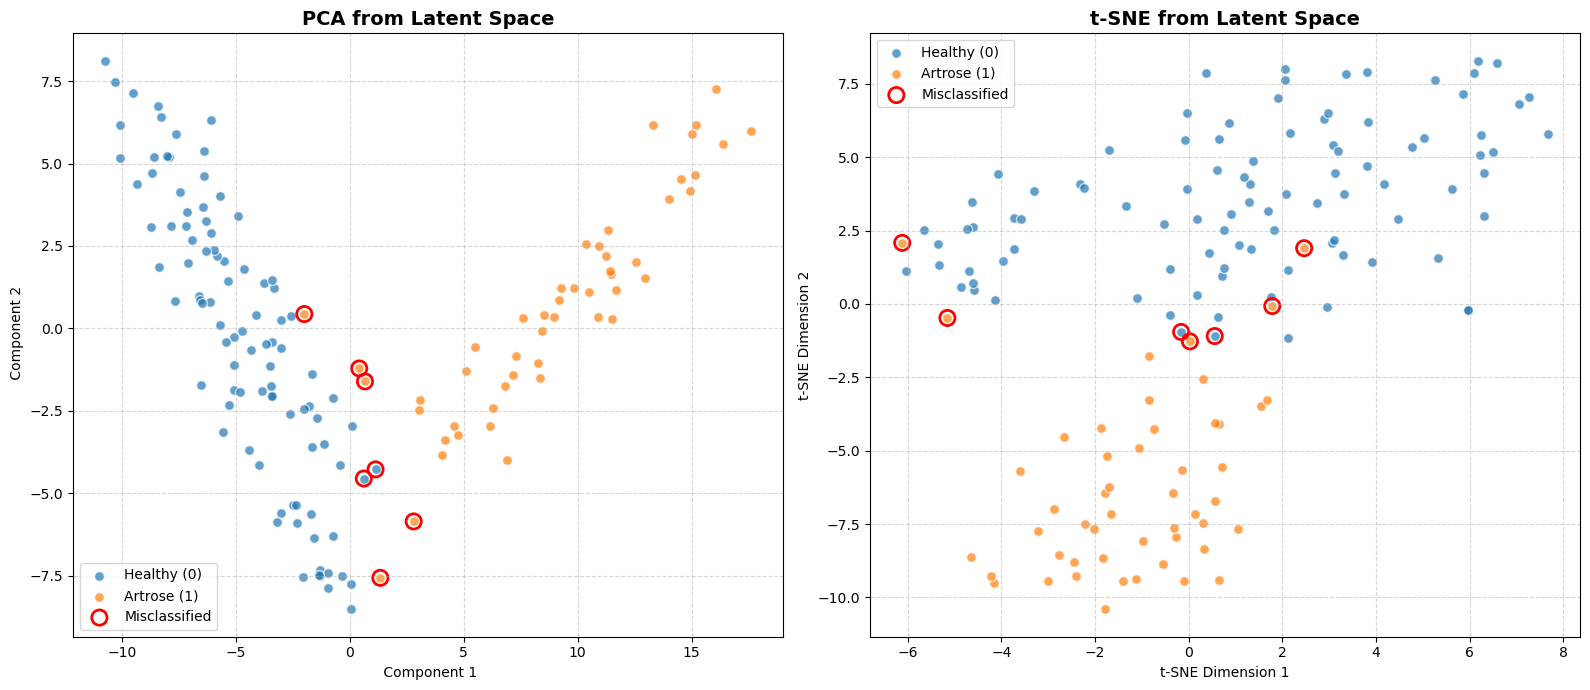

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#1f77b4', '#ff7f0e'] # Blue = healthy, orange= artrose
target_names = ['Healthy (0)', 'Artrose (1)']

#PCA
for i, color, target_name in zip([0, 1], colors, target_names):
    axes[0].scatter(latent_pca[true_labels == i, 0],
                    latent_pca[true_labels == i, 1],
                    color=color, alpha=0.7, label=target_name, edgecolors='w', s=50)
#add misclassified marker
axes[0].scatter(
    latent_pca[error_indices, 0],
    latent_pca[error_indices, 1],
    facecolors='none',
    edgecolors='red',
    s=120,
    linewidths=2,
    label='Misclassified'
)

axes[0].set_title("PCA from Latent Space", fontsize=14, fontweight='bold')
axes[0].set_xlabel(" Component 1")
axes[0].set_ylabel(" Component 2")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

#t-SNE
for i, color, target_name in zip([0, 1], colors, target_names):
    axes[1].scatter(latent_tsne[true_labels == i, 0],
                    latent_tsne[true_labels == i, 1],
                    color=color, alpha=0.7, label=target_name, edgecolors='w', s=50)

axes[1].scatter(
    latent_tsne[error_indices, 0],
    latent_tsne[error_indices, 1],
    facecolors='none',
    edgecolors='red',
    s=120,
    linewidths=2,
    label='Misclassified'
)

axes[1].set_title("t-SNE from Latent Space", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

##### Latent space structure: Do healthy knees and severe osteoarthritis cases form distinctclusters in the latent space?
 
With both PCA and t-SNE, the features in the latent space manage to separate into distinct clusters of healthy and osteoarthritis cases. Both cases are separated to opposite sides of the of the graph. While the clusters may differ in shape, size and proximity, an imaginary line can always be drawn between the two cases. Interestingly, some points in the latent space that are classified as one class, may look to be closer to the other class’s cluster. This overlap between the clusters could suggest that the points in between them could be misclassified, or more difficult cases to classify than others.

##### Dimensionality reduction methods: What differences do you observe between the PCA and t-SNE visualizations? Describe your observations regarding the latent space structure.
The PCA visualization seems to have more concentrated clusters, with points being closer to each other than the t-SNE visualization, whose points are less densely grouped. As a consequence, the cluster overlap with t-SNE appears higher than with PCA, meaning that some points of a certain class protrude more deeply into the opposite cluster.

##### Misclassified samples: Where do misclassified samples appear in the latent space?
When misclassified samples are highlighted, it is clear that in both visualizations, these cases only appear on the border area between the clusters. 

##### Interpretation: What can these observations tell you about the model’s behavior and the intrinsic difficulty of the classification task?
These observations suggest that the model has learned meaningful features, as it is able to largely separate healthy and osteoarthritis cases in the latent space. The structure of the PCA and t-SNE graphs also indicates that the model is able to recognise underlying patterns that are relevant to the diagnosis.
However, with both PCA and t-SNE visualizations, there are areas where cases of different classes come in very close proximity. This proximity suggests that there is little difference between the features of these cases which makes it inherently difficult for the model to differentiate them into the correct class. This theory is reinforced by the fact that many of the misclassified cases appear in the border region, in close proximity to cases of both classes.
